# Support Vector Machines nos dados covtype de LIBSVM

Iremos treinar os dados para classificação binária usando os dados `covtype` da biblioteca [LIBSVM](https://www.csie.ntu.edu.tw/~cjlin/libsvm/). Veja também [Kaggle-LIBSVM](https://www.kaggle.com/code/tanmayunhale/libsvm-liblinear).

Desta vez, iremos usar o algoritmo SVM:

$$
\min_{w\in {\mathbb R}^{d\times1}} f_n(w)=\frac{1}{n}\sum_{i=1}^n \max\{0,1-y_i(x_i^\top w)\} + \frac{\gamma}{2}\|w\|^2,
$$

onde $x_i\in {\mathbb R}^{d\times1}$, $y_i\in \{-1, 1\}$. Uma diferença em relação à regressão logística é que a função custo não é diferenciável. Um subgradiente num ponto $w$ é dado por

$$
g_n(w) = -\frac{1}{n}\sum_{i=1}^n\mathbb{1}_{\{y_i(x_i^\top w)<1\}}y_ix_i + \gamma w.
$$

Portanto, poderíamos usar o método subgradiente. Neste projeto, entretanto, iremos considerar o caso em que $n$ é muito grande de modo que avaliar $f(w)$ ou $g(w)$ é muito custoso. Note que $f(w)$ é a média empírica de 

$$
F_i(w) := \max\{0,1-y_i(x_i^\top w)\} + \frac{\gamma}{2}\|w\|^2.
$$

Alternativamente iremos usar em cada iteração um único ponto da amostra e aplicar o método subgradiente estocástico com o subgradiente:

$$
G_i(w) := -\mathbb{1}_{\{y_i(x_i^\top w)<1\}}y_ix_i + \gamma w.
$$

NOTA: neste projeto os labels devem estar em $\{-1,1\}$!

In [1]:

import matplotlib
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.linalg as la
from sklearn.datasets import load_svmlight_file
from sklearn.utils.extmath import safe_sparse_dot

In [2]:
# Lendo os dados do arquivo covtype e guardando na matriz de dados X e vetor de labels y:

data = load_svmlight_file('./datasets/covtype.bz2')
X, y = data[0].toarray(), data[1]
if (np.unique(y) == [1, 2]).all():
    # Devemos garantir que os labels estão em {-1, 1}
    y[y==1.] = -1
    y[y==2.] = 1
    
n, d = X.shape # tamanho da amostra, número de features    

# Exercício 1: Funções auxiliares

1. Construa uma função `f(w, l2, m)` que toma o iterado `w` e a penalização $\gamma$ (=`l2`) e retorna o valor funcional $f_{m}(w)$ para algum $m\in[n]$.
2. Construa uma função `G(w, i, l2)` toma o iterado `w`, os dados $(x_i,y_i)$ e a penalização $\gamma$ (=`l2`) e retorna o subgradiente $G_i(w)$.
3. Construa uma função `g(w, l2, m)` que toma o iterado `w` e a penalização $\gamma$ (=`l2`) e retorna o subgradiente  $g_{m}(w)$ para algum $m\in[n]$ --- isto é, a média de $m$ subgradientes.
4. Construa uma função `gB(w, l2, B)` que toma o iterado `w` e a penalização $\gamma$ (=`l2`) e retorna o gradiente  $g_{B}(w)=\frac{1}{B}\sum_{i\in I_B}G_i(w)$ para algum $B\in[n]$ onde $I_B\subset[n]$ é escolhido aleatoriamente/uniformente. 

In [3]:
def f(w, l2, m):
    y2 = y[:m]
    X2 = X[:m]
    return (1 / m) * np.sum(np.maximum(0, 1 - y2 * (X2 @ w))) + (l2 / 2) * (w.T @ w)

In [4]:
def G(w, i, l2):
    if y[i] *( X[i].T @ w) < 1: 
        return -y[i] * X[i] + l2 * w
    else:
        return l2 * w

In [5]:
def g(w, l2, m):
    y2 = y[:m]
    X2 = X[:m]
    return -(1 / m) * np.sum((y2 * (X2 @ w) < 1).astype(np.uint8) * ((y2 * (X2.T)).T)) + l2 * w

In [6]:
def gB(w, l2, B):
    Ib = np.random.choice(a=n, size=B, replace=False)
    y2 = y[Ib]
    X2 = X[Ib]
    u = (y2 * (X2 @ w) < 1).astype(np.uint8)
    v = y2[:, np.newaxis] * X2
    t = -(u[:, np.newaxis] * v)
    return (1 / B) * (np.sum(t, axis=0)) + l2 * w

# Inicialização

Fixaremos:

In [7]:
m = 30000
l2 = 1e+2
w0 = np.zeros(d)        # ponto inicial
it_max = 80001         # número de iterações
B = 100

batch_size = 1000

# Exercício 2: Método subgradiente estocástico 1 

Iremos implementar o algoritmo [Pegasos](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.cs.huji.ac.il/~shais/papers/ShalevSiSrCo10.pdf)

Construa uma função `sgd(f, G, w0, lr, l2, m, it_max)` que toma como entrada as funções `g()` `G()`, o ponto inicial `w0`, a regularização `l2` $(=\gamma)$, passo `lr`,  `m` e implementa o método subgradiente estocástico em `it_max` iterações iniciando de `w0`:

$$
w_{k+1} = w_k - \alpha_k G_k(w_k), 
$$

com passo $\alpha_k=\frac{lr}{\gamma k}$. **Na $k$-ézima iteração, use o ponto amostral $(x_k,y_k)$, na ordem do data set `X,y`**. Esta função deve retornar a sequência 

$$
k\mapsto f_{m}(w_k)=\frac{1}{m}\sum_{i=1}^{m} \max\{0,1-y_i(x_i^\top w_k)\} + \frac{\gamma}{2}\|w_k\|^2.
$$  

A função também deve retornar o último iterado.

In [8]:
def sgd(f, G, w0, lr, l2, m, it_max):
    w = w0.copy()
    errors = []
    for k in range(it_max):
        a = lr / (l2 * (k + 1))
        w = w - a * G(w, k, l2)
        if k % batch_size == 0: errors.append(f(w, l2, m))

    return errors, w

In [36]:
# gradient descent
f1 = sgd(f, G, w0, 1e-1, l2, m, it_max)

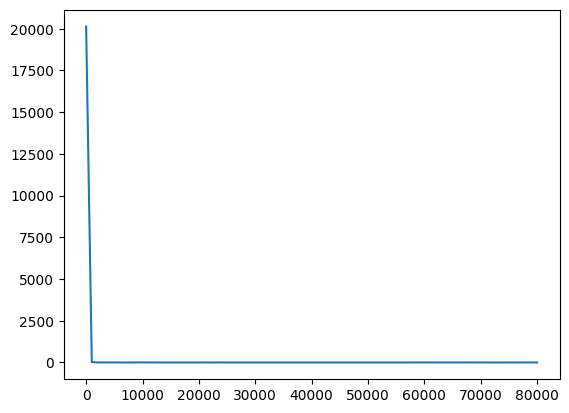

In [37]:
x = np.arange(len(f1[0])) * batch_size
plt.plot(x, f1[0])

# Exercício 3: Método subgradiente estocástico 2

Construa uma função `sgd2(f, G, w0, lr, l2, m, it_max)` que toma como entrada as funções `g` `G()`, o ponto inicial `w0`, a regularização `l2` $(=\gamma)$, `m` e implementa o método subgradiente estocástico em `it_max` iterações iniciando de `w0`:

$$
w_{k+1} = w_k - \alpha_k G_{i_k}(w_k),
$$

com passo $\alpha_k=\frac{lr}{\gamma k}$, onde **na $k$-ézima iteração, $i_k\in[n]$ é escolhido uniformemente ao acaso, usand o ponto amostral $(x_{i_k},y_{i_k})$**. Esta função deve retornar a sequência 

$$
k\mapsto f_{m}(w_k)=\frac{1}{m}\sum_{i=1}^{m} \max\{0,1-y_i(x_i^\top w_k)\} + \frac{\gamma}{2}\|w_k\|^2.
$$ 

A função também deve retornar o último iterado.

In [9]:
def sgd2(f, G, w0, lr, l2, m, it_max):
    w = w0.copy()
    errors = []
    for k in range(it_max):
        a = lr / (l2 * (k + 1))
        ik = np.random.randint(n) 
        w = w - a * G(w, ik, l2)
        if k % batch_size == 0: errors.append(f(w, l2, m))

    return errors, w

In [39]:
# gradient descent
f2 = sgd2(f, G, w0, 1e-1, l2, m, it_max)

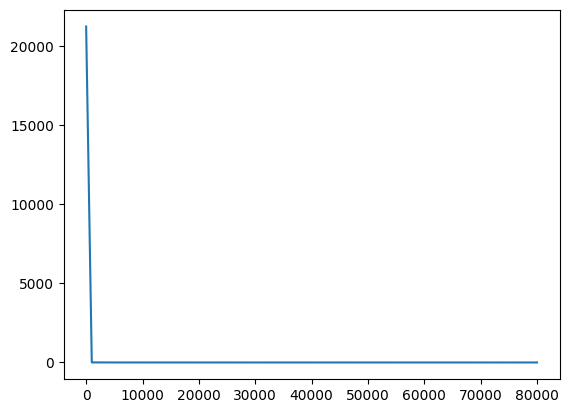

In [40]:
x = np.arange(len(f2[0])) * batch_size
plt.plot(x, f2[0])

# Exercício 4: Método subgradiente estocástico 3

Construa agora função `sgd3(f, gB, w0, lr, l2, m, B, it_max)` que toma como entrada as funções `f` `gB()`, o ponto inicial `w0`, a regularização `l2` $(=\gamma)$ e implementa o método subgradiente estocástico com mini-batch size `B` em `it_max` iterações iniciando de `w0`:

$$
w_{k+1} = w_k - \alpha_k \cdot\frac{1}{B}\sum_{i\in B_k}G_{i}(w_k),
$$

onde **na $k$-ézima iteração, $B_k\subset\in[n]$ é escolhido uniformemente ao acaso, usando o mini-batch $\{(x_{i},y_{i})\}_{i\in B_k}$**. Esta função deve retornar a sequência 

$$
k\mapsto f_{\text{it_max}}(w_k)=\frac{1}{\text{it_max}}\sum_{i=1}^{\text{it_max}} \max\{0,1-y_i(x_i^\top w_k)\} + \frac{\gamma}{2}\|w_k\|^2.
$$ 

A função também deve retornar o último iterado. Implemente com passo $\alpha_k=\frac{lr}{\gamma k}$.  

In [10]:
def sgd3(f, gB, w0, lr, l2, m, B, it_max):
    w = w0.copy()
    errors = []
    for k in range(it_max):
        a = lr / (l2 * (k + 1))
        w = w - a * gB(w, l2, B)
        if k % batch_size == 0:
            print(k / it_max) 
            errors.append(f(w, l2, m))

    return errors, w

In [42]:
f3 = sgd3(f, gB, w0, 1e-1, l2, m, B, it_max)

0.0
0.0124998437519531
0.0249996875039062
0.0374995312558593
0.0499993750078124
0.0624992187597655
0.0749990625117186
0.08749890626367171
0.0999987500156248
0.11249859376757791
0.124998437519531
0.1374982812714841
0.1499981250234372
0.1624979687753903
0.17499781252734342
0.18749765627929652
0.1999975000312496
0.2124973437832027
0.22499718753515582
0.23749703128710892
0.249996875039062
0.2624967187910151
0.2749965625429682
0.2874964062949213
0.2999962500468744
0.31249609379882753
0.3249959375507806
0.3374957813027337
0.34999562505468684
0.3624954688066399
0.37499531255859303
0.3874951563105461
0.3999950000624992
0.41249484381445234
0.4249946875664054
0.4374945313183585
0.44999437507031165
0.4624942188222647
0.47499406257421783
0.4874939063261709
0.499993750078124
0.5124935938300771
0.5249934375820302
0.5374932813339833
0.5499931250859365
0.5624929688378896
0.5749928125898426
0.5874926563417957
0.5999925000937488
0.612492343845702
0.6249921875976551
0.6374920313496081
0.6499918751015612


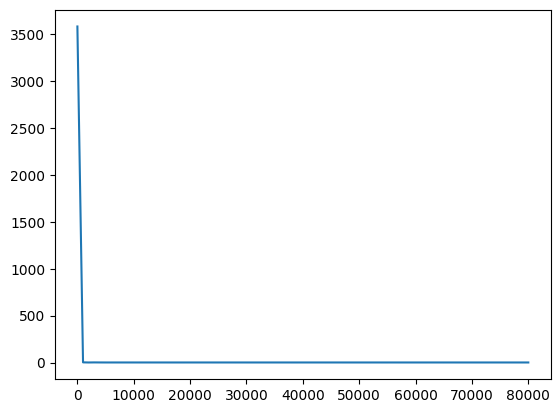

In [43]:
x = np.arange(len(f3[0])) * batch_size
plt.plot(x, f3[0])

# Exercício 5: 

Implemente num mesmo gráfico os erros $f_{\text{it_max}}(w_k)$ de cada método em função no número de iterações.

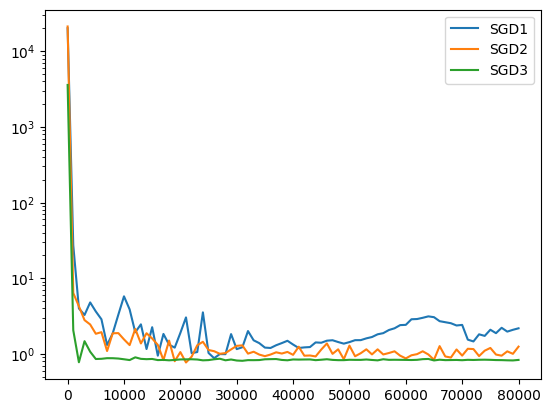

In [44]:
x = np.arange(len(f3[0])) * batch_size
r = 0
plt.plot(x[r:], f1[0][r:], label="SGD1")
plt.plot(x[r:], f2[0][r:], label="SGD2")
plt.plot(x[r:], f3[0][r:], label="SGD3")
plt.legend()
plt.yscale('log')
plt.show()

# Exercício 6:

Nos exercícios anteriores, usamos os $m$ primeiros pontos de dados `y[:m], X[:m]` para plotar a sequência $k\mapsto f_m(w_k)$. Isto não é ideal já que usamos também todo ou parte de `y[:m], X[:m]` para construir a sequência de iterados $k\mapsto w_k$. Refaça os 3 exercícios anteriores mas antes dividindo o data set `y, X` em duas partes 
`y[n-m:], X[n-m:]` e `y[:n-m], X[:n-m]`. Use o dataset `y[:n-m], X[:n-m]` de tamanho `n-m` para construir a sequência de iterados $k\mapsto w_k$ e `y[n-m:], X[n-m:]` de tamanho `m` para computar $f_m(w)$ para cada iterado $w$. Plote os 3 gráficos correspondentes e depois o gráfico com os 6 métodos diferentes. Você nota alguma diferença?

In [11]:
def fm(w, l2, m):
    y2 = y[n-m:]
    X2 = X[n-m:]
    return (1 / m) * np.sum(np.maximum(0, 1 - y2 * (X2 @ w))) + (l2 / 2) * (w.T @ w)

def Gm(w, i, l2):
    ym = y[:n-m]
    Xm = X[:n-m]
    if ym[i] *( Xm[i].T @ w) < 1: 
        return -ym[i] * Xm[i] + l2 * w
    else:
        return l2 * w
    
def gBm(w, l2, B):
    Ib = np.random.choice(a=n-m, size=B, replace=False)
    y2 = y[:n-m][Ib]
    X2 = X[:n-m][Ib]
    u = (y2 * (X2 @ w) < 1).astype(np.uint8)
    v = y2[:, np.newaxis] * X2
    t = -(u[:, np.newaxis] * v)
    return (1 / B) * (np.sum(t, axis=0)) + l2 * w    

In [12]:
def sgd2m(f, G, w0, lr, l2, m, it_max):
    w = w0.copy()
    errors = []
    for k in range(it_max):
        a = lr / (l2 * (k + 1))
        ik = np.random.randint(n-m) 
        w = w - a * G(w, ik, l2)
        if k % batch_size == 0: errors.append(f(w, l2, m))

    return errors, w

In [13]:
def sgd3m(f, gB, w0, lr, l2, m, B, it_max):
    w = w0.copy()
    errors = []
    for k in range(it_max):
        a = lr / (l2 * (k + 1))
        w = w - a * gB(w, l2, B)
        if k % batch_size == 0:
            print(k / it_max) 
            errors.append(f(w, l2, m))

    return errors, w

In [14]:
f1m = sgd(fm, Gm, w0, 1e-1, l2, m, it_max)
f2m = sgd2m(fm, Gm, w0, 1e-1, l2, m, it_max)
f3m = sgd3m(fm, gBm, w0, 1e-1, l2, m, B, it_max)


0.0
0.0124998437519531
0.0249996875039062
0.0374995312558593
0.0499993750078124
0.0624992187597655
0.0749990625117186
0.08749890626367171
0.0999987500156248
0.11249859376757791
0.124998437519531
0.1374982812714841
0.1499981250234372
0.1624979687753903
0.17499781252734342
0.18749765627929652
0.1999975000312496
0.2124973437832027
0.22499718753515582
0.23749703128710892
0.249996875039062
0.2624967187910151
0.2749965625429682
0.2874964062949213
0.2999962500468744
0.31249609379882753
0.3249959375507806
0.3374957813027337
0.34999562505468684
0.3624954688066399
0.37499531255859303
0.3874951563105461
0.3999950000624992
0.41249484381445234
0.4249946875664054
0.4374945313183585
0.44999437507031165
0.4624942188222647
0.47499406257421783
0.4874939063261709
0.499993750078124
0.5124935938300771
0.5249934375820302
0.5374932813339833
0.5499931250859365
0.5624929688378896
0.5749928125898426
0.5874926563417957
0.5999925000937488
0.612492343845702
0.6249921875976551
0.6374920313496081
0.6499918751015612


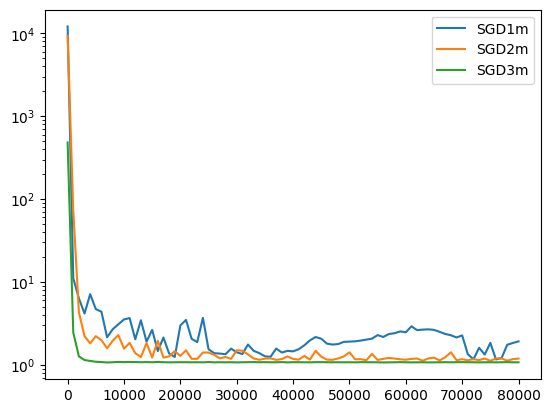

In [17]:
x = np.arange(len(f3[0])) * batch_size
r = 0
plt.plot(x[r:], f1m[0][r:], label="SGD1m")
plt.plot(x[r:], f2m[0][r:], label="SGD2m")
plt.plot(x[r:], f3m[0][r:], label="SGD3m")
plt.legend()
plt.yscale('log')
plt.show()

In [15]:

f1 = sgd(f, G, w0, 1e-1, l2, m, it_max)
f2 = sgd2(f, G, w0, 1e-1, l2, m, it_max)
f3 = sgd3(f, gB, w0, 1e-1, l2, m, B, it_max)

0.0
0.0124998437519531
0.0249996875039062
0.0374995312558593
0.0499993750078124
0.0624992187597655
0.0749990625117186
0.08749890626367171
0.0999987500156248
0.11249859376757791
0.124998437519531
0.1374982812714841
0.1499981250234372
0.1624979687753903
0.17499781252734342
0.18749765627929652
0.1999975000312496
0.2124973437832027
0.22499718753515582
0.23749703128710892
0.249996875039062
0.2624967187910151
0.2749965625429682
0.2874964062949213
0.2999962500468744
0.31249609379882753
0.3249959375507806
0.3374957813027337
0.34999562505468684
0.3624954688066399
0.37499531255859303
0.3874951563105461
0.3999950000624992
0.41249484381445234
0.4249946875664054
0.4374945313183585
0.44999437507031165
0.4624942188222647
0.47499406257421783
0.4874939063261709
0.499993750078124
0.5124935938300771
0.5249934375820302
0.5374932813339833
0.5499931250859365
0.5624929688378896
0.5749928125898426
0.5874926563417957
0.5999925000937488
0.612492343845702
0.6249921875976551
0.6374920313496081
0.6499918751015612


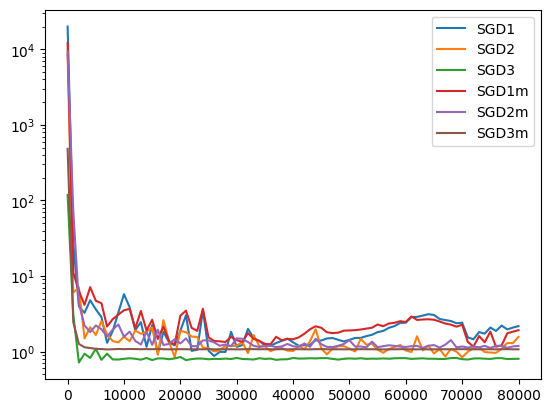

In [16]:
x = np.arange(len(f3[0])) * batch_size
r = 0
plt.plot(x[r:], f1[0][r:], label="SGD1")
plt.plot(x[r:], f2[0][r:], label="SGD2")
plt.plot(x[r:], f3[0][r:], label="SGD3")
plt.plot(x[r:], f1m[0][r:], label="SGD1m")
plt.plot(x[r:], f2m[0][r:], label="SGD2m")
plt.plot(x[r:], f3m[0][r:], label="SGD3m")
plt.legend()
plt.yscale('log')
plt.show()

É notado que os erros para os métodos que utilizam os dados inteiros são menores. Isto é esperado, visto que quando treinamos com os mesmos dados que iremos testar nós estamos enviezando o modelo. Assim o desempenho será melhor do que quando nós separamos os dados em treino e teste.